This notebook is used to run full graph discovery. We use the Rossler oscillator as an example.

The data used for this tutorial is stored under `tutorial/data/` directory.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import copy
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import torch

from kausal import Graph
from kausal.observables import RandomFourierFeatures, TimeDelayFeatures, MLPFeatures
from kausal.utils import score

import warnings
warnings.filterwarnings('ignore')


# Graph discovery

Graph discovery is simply performing pairwise tests but over every combination of nodes.

The `Graph` API expects input of shapes:
- `num_nodes`: number of variables
- `num_vars`: dimensionality of each node (for now it expects identical dimensionality across nodes)
- `num_steps`: length of the timeseries

In [3]:
# Load data
DATA_PATH = Path('data/')
ds = xr.open_dataset(DATA_PATH / 'Rossler_N10_T1000.nc')
adj_matrix = ds['adjacency_matrix'].to_numpy()
timeseries = ds['time_series'].to_numpy().transpose(1, 2, 0)[:, :, None, :] 
timeseries = timeseries[-1] # Selecting a sample realization

print(timeseries.shape) # (num_nodes, num_vars, num_steps)


(3, 1, 1000)


In [4]:
# Kausal (Graph discovery mode)
hidden_channels = [8, 16]
lr = 1e-3
epochs = 1
n_train = int(0.8 * timeseries.shape[-1])

## Initialize the Graph object
graph_model = Graph(
    marginal_observable = MLPFeatures(in_channels=1, hidden_channels=hidden_channels, out_channels=1),
    joint_observable = MLPFeatures(in_channels=2, hidden_channels=hidden_channels, out_channels=1)
)

## Make inference given a time shift, and any parameters needed e.g., fit_kwargs, bootstrap_kwargs
## Under the hood, .infer() will execute the .fit() and .evaluate() operations needed in the standalone Kausal object.
graph_model.infer(
    X = torch.tensor(timeseries),
    time_shift = 100,
    fit_kwargs = {'n_train': n_train, 'epochs': epochs, 'lr': lr, 'batch_size': n_train},
    bootstrap_kwargs = {'bootstrap_ratio': 0.9, 'bootstrap_nums': 30}
)

## Scoring
kausal_adj_matrix = copy.deepcopy(
    graph_model.get_adjacency(p_crit=0.05)
)

score(
    preds= np.array(kausal_adj_matrix),
    labs= adj_matrix,
    name='Kausal'
)

,Kausal
Metric,
Joint AUROC,0.833333
Individual AUROC,0.833333
Null AUROC,0.500000
Joint AUPRC,0.857143
Individual AUPRC,0.857143
Null AUPRC,0.666667
Joint SHD,1.000000


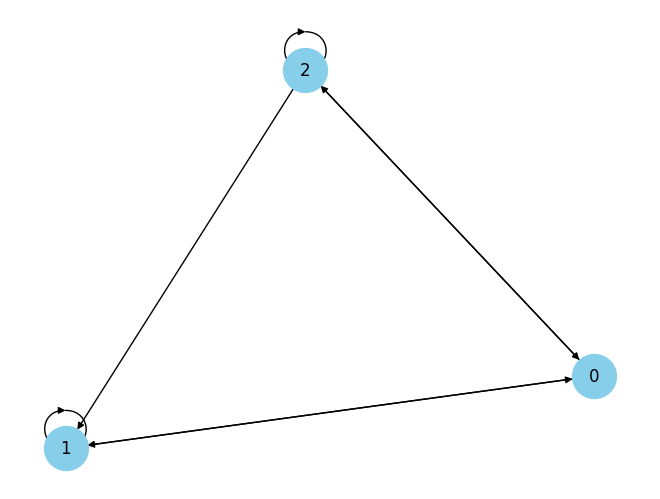

In [5]:
# You can plot the discovered graph
graph_model.plot_adjacency()

In [6]:
# Also print the results in more detail (mean, std causal measures and their corresponding p-value)
graph_model.print_result()

          mean       std      pval
0->0 -0.000996  0.001308  0.709677
0->1  5.004298  0.162766  0.032258
0->2  1.099361  0.023406  0.032258
1->0  2.614753  0.148498  0.032258
1->1  0.000920  0.000324  0.032258
1->2 -0.219905  0.043680  1.000000
2->0  0.375703  0.013318  0.032258
2->1  0.945210  0.009722  0.032258
2->2  0.409093  0.006496  0.032258


In [7]:
# Or get the adjacency matrix
graph_model.get_adjacency()

tensor([[0, 1, 1],
        [1, 1, 0],
        [1, 1, 1]], dtype=torch.int32)